In [12]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from sympy.physics.mechanics import dynamicsymbols, init_vprinting
init_vprinting()

class AxisymmetricVariableMassSystem:
    def __init__(self):
        self.t_symbolic = dynamicsymbols('t')
        # Mass and its derivative
        self.m_symbolic = dynamicsymbols('m')
        self.m_dot_symbolic = dynamicsymbols('m', 1)  # First derivative of mass
        
        # Moments of inertia
        self.I_symbolic = dynamicsymbols('I')  # Transverse moment of inertia 
        self.J_symbolic = dynamicsymbols('J')  # Axial moment of inertia
        
        self.ze_symbolic = dynamicsymbols('ze')  # Distance of center of mass from exit plane 

        # First derivatives of moments of inertia
        self.I_dot_symbolic = dynamicsymbols('I', 1)  # First derivative of transverse moment
        self.J_dot_symbolic = dynamicsymbols('J', 1)  # First derivative of axial moment

        # Initial angular velocities
        self.omega_1_initial_symbolic = dynamicsymbols('omega_10')
        self.omega_2_initial_symbolic = dynamicsymbols('omega_20') 
        self.omega_3_initial_symbolic = dynamicsymbols('omega_30')

        # Angular accelerations
        self.omega_1_dot_symbolic = dynamicsymbols('omega_1', 1)
        self.omega_2_dot_symbolic = dynamicsymbols('omega_2', 1) 
        self.omega_3_dot_symbolic = dynamicsymbols('omega_3', 1)
        # self.omega_12_symbolic = dynamicsymbols('omega_12')
        # self.omega_12_mag_symbolic = sp.sqrt(self.omega_1_symbolic**2 + self.omega_2_symbolic**2)
        
        # Euler angles
        self.phi_symbolic = dynamicsymbols('phi')      # First rotation about z
        self.theta_symbolic = sp.atan(self.I_symbolic/self.J_symbolic * self.omega_12_symbolic/self.omega_3_symbolic)
        self.psi_symbolic = dynamicsymbols('psi')      # Third rotation about z''
        # Euler angle rates
        # self.phi_dot_symbolic = dynamicsymbols('phi', 1)
        # self.psi_dot_symbolic = dynamicsymbols('psi', 1)
        self.theta_dot_symbolic = sp.atan(self.I_symbolic/self.J_symbolic * self.omega_12_symbolic/self.omega_3_symbolic)

    @property
    def omega_1_symbolic(self):
        """Symbolic representation of omega_1"""
        return dynamicsymbols('omega_1')
    
    @property
    def omega_2_symbolic(self):
        """Symbolic representation of omega_2"""
        return dynamicsymbols('omega_2')
    
    @property
    def omega_3_symbolic(self):
        """Symbolic representation of omega_3"""
        return dynamicsymbols('omega_3')
    
    @property
    def omega_12_symbolic(self):
        """Symbolic representation of omega_12"""
        return dynamicsymbols('omega_12')
    
    @property
    def omega_12_mag_symbolic(self):
        """Symbolic representation of omega_12_mag"""
        return sp.sqrt(self.omega_1_symbolic**2 + self.omega_2_symbolic**2)

class VariableMassCylinder(AxisymmetricVariableMassSystem):
    def __init__(self, burn_type='uniform'):
        """
        Initialize a variable mass cylinder with specified burn type.
        
        Parameters:
        burn_type (str): Type of burn - 'uniform', 'radial', or 'end'
        """
        super().__init__()
        self.burn_type = burn_type
        # Default physical parameters
        self.rho_ini_symbolic = dynamicsymbols('rho_0')  # kg/m^3
        self.rho_ini = 1020  # kg/m^3
        self.rho_exhaust_symbolic = dynamicsymbols('rho_exhaust')  # kg/m^3
        self.rho_exhaust = 0.002 * self.rho_ini  # kg/m^3
        self.R_symbolic = dynamicsymbols('R')  # m
        self.R = 1.0  # m
        self.h_symbolic = dynamicsymbols('h')  # m
        self.h = self.R / 5  # m
        self.L_symbolic = dynamicsymbols('L')  # m 
        self.L = 2 * self.h # m
        self.u_symbolic = dynamicsymbols('u')  # m/s
        self.u = 5.0  # m/s
        self.m_dot = -self.rho_exhaust * self.u * np.pi * self.R**2
        self.m0 = np.pi * self.R**2 * self.L * self.rho_ini
            # self.tf = -self.m0 / self.m_dot - 1
        # # Calculate mass flow rate, burn time from simulations as well as some of the inertia terms based on burn type
        if burn_type == 'uniform' or burn_type == 'no_burn':
            self.tf = -self.m0 / self.m_dot - 1  # Burn time
            # self.ze = self.h  # Distance of center of mass from exit plane
            # Symbolic moments of inertia for uniform burn
            self.I1_symbolic_uniform = self.m_symbolic * (self.R_symbolic**2/4 + self.h_symbolic**2/3)  # I = m(R^2/4 + h^2/3)
            self.I3_symbolic_uniform = self.m_symbolic * self.R_symbolic**2/2  # J = mR^2/2
            self.I1_dot_symbolic_uniform = self.m_dot_symbolic * (self.R_symbolic**2 / 4 + self.h_symbolic**2 / 3)
            self.I3_dot_symbolic_uniform = self.m_dot_symbolic * self.R_symbolic**2 / 2
        elif burn_type == 'end':
            self.tf = -self.m0 / self.m_dot  # Burn time
            self.z_symbolic = dynamicsymbols('z')  # Distance of center of mass from exit plane
            # Symbolic moments of inertia for end burn
            self.I1_symbolic_end = self.m_symbolic * (self.R_symbolic**2/4 + self.z_symbolic**2/3)  # I = m(R^2/4 + z^2/3)
            self.I3_symbolic_end = self.m_symbolic * self.R_symbolic**2/2  # J = mR^2/2
            self.ze_t = []
            self.I1_dot_symbolic_end = self.m_dot_symbolic * (self.R_symbolic**2/4 + self.z_symbolic**2)
            self.I3_dot_symbolic_end = self.m_dot_symbolic * self.R_symbolic**2/2
            # self.z0 = self.h  # Initial distance of center of mass from exit plane
        elif burn_type == 'radial':
            # self.tf = 90  # Burn time from radial burn example
            self.tf = -self.m0 / self.m_dot - 1  # Burn time
            self.r_symbolic = dynamicsymbols('r') # Inner radius of radial burn
            # Symbolic moments of inertia for radial burn
            self.I1_symbolic_radial = self.m_symbolic * (1/4 * (self.R_symbolic**2 + self.r_symbolic**2) + self.h_symbolic**2/3)  # I = m[1/4(R^2 + r^2) + h^2/3]
            self.I3_symbolic_radial = self.m_symbolic * (self.R_symbolic**2 + self.r_symbolic**2)/2  # J = m(R^2 + r^2)/2
            self.I1_dot_symbolic_radial = self.m_dot_symbolic * (self.r_symbolic**2/2 + self.h_symbolic**2/3)
            self.I3_dot_symbolic_radial = self.m_dot_symbolic * (self.r_symbolic**2)
            # self.rsq0 = 0; # Initial inner radius
            # self.ze = self.h  # Distance of center of mass from exit plane
    
    def _no_burn_derivatives(self, t, y):
        """Equations of motion for constant mass system."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Chi, F = y
        
        # Numeric versions
        I1_dot = (self.I1_dot_symbolic_uniform.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R,
            self.h_symbolic: self.h
        })) * 0

        I3_dot = (self.I3_dot_symbolic_uniform.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R
        })) * 0

        m_dot = self.m_dot * 0
        # Angular velocity derivatives
        w1_dot =  (I1 - I3) * w2 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4) ) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4) ) * w2 / I1
        w3_dot = -(I3_dot - m_dot * self.R**2 / 2) * w3 / I3
        
        Chi_Dot = (1 - I3/I1)*w3
        F_dot = -(I1_dot - m_dot * (self.R**2/4 + self.ze**2))/I1
        
        # Euler angle rates
        w12 = np.sqrt(w1**2 + w2**2)
        w12_dot = (w1*w1_dot + w2*w2_dot)/w12
        theta_dot = ((I1 * w12_dot + w12 * I1_dot) * I3 * w3 - I1 * I3 * w12 * w3_dot - I1 * w12 * w3 * I3_dot) / (I1**2 * w12**2 + I3**2 * w3**2)
        phi_dot = ((I3/I1 * w3/np.cos(theta))**2 - theta_dot/np.tan(theta)**2)**0.5
        psi_dot = w3 - phi_dot * np.cos(theta)
        
        return [m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot]

    def _uniform_burn_derivatives(self, t, y):
        """Equations of motion for uniform burn."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Chi, F = y
        
        # Numeric versions
        I1_dot = self.I1_dot_symbolic_uniform.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R,
            self.h_symbolic: self.h
        })

        I3_dot = self.I3_dot_symbolic_uniform.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R
        })

        m_dot = self.m_dot
        # Angular velocity derivatives
        w1_dot =  (I1 - I3) * w2 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4) ) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4) ) * w2 / I1
        w3_dot = -(I3_dot - m_dot * self.R**2 / 2) * w3 / I3
        
        Chi_Dot = (1 - I3/I1)*w3
        F_dot = -(I1_dot - m_dot * (self.R**2/4 + self.ze**2))/I1
        
        # Euler angle rates
        w12 = np.sqrt(w1**2 + w2**2)
        w12_dot = (w1*w1_dot + w2*w2_dot)/w12
        theta_dot = ((I1 * w12_dot + w12 * I1_dot) * I3 * w3 - I1 * I3 * w12 * w3_dot - I1 * w12 * w3 * I3_dot) / (I1**2 * w12**2 + I3**2 * w3**2)
        phi_dot = ((I3/I1 * w3/np.cos(theta))**2 - theta_dot/np.tan(theta)**2)**0.5
        psi_dot = w3 - phi_dot * np.cos(theta)
        
        return [m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot]

    def _end_burn_derivatives(self, t, y):
        """Equations of motion for end burn."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Theta, F, z = y
        
        # Mass varying terms
        I1_dot = self.I1_dot_symbolic_end.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R,
            self.z_symbolic: z
        })

        I3_dot = self.I3_dot_symbolic_end.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R
        })

        # Distance of mass center from exit plane
        ze_end_burn = 2 * self.h - z
        # print("ze_end_burn: ", ze_end_burn)

        # Equations of motion for the axisymmetric cylinder
        m_dot = self.m_dot
        z_dot = m_dot/m * z
        w1_dot =  (I1 - I3) * w2 * w3 / I1 - (I1_dot - m_dot * (ze_end_burn**2 + self.R**2 / 4) ) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - m_dot * (ze_end_burn**2 + self.R**2 / 4) ) * w2 / I1
        # w1_dot =  (I1 - I3) * w2 * w3 / I1 - (m_dot * (z**2 - ze_end_burn**2) ) * w1 / I1
        # w2_dot = -(I1 - I3) * w1 * w3 / I1 - (m_dot * (z**2 - ze_end_burn**2) ) * w2 / I1
        w3_dot = -(I3_dot - m_dot * self.R**2/2) * w3 / I3
        Chi_Dot = (1 - I3/I1) * w3
        F_dot = -(I1_dot - m_dot * (ze_end_burn**2 + self.R**2/4)) / I1
        
        # Euler angle rates
        # Euler angle rates
        w12 = np.sqrt(w1**2 + w2**2)
        w12_dot = (w1*w1_dot + w2*w2_dot)/w12
        theta_dot = ((I1 * w12_dot + w12 * I1_dot) * I3 * w3 - I1 * I3 * w12 * w3_dot - I1 * w12 * w3 * I3_dot) / (I1**2 * w12**2 + I3**2 * w3**2)
        phi_dot = ((I3/I1 * w3/np.cos(theta))**2 - theta_dot/np.tan(theta)**2)**0.5
        psi_dot = w3 - phi_dot * np.cos(theta)
        
        return [m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot, z_dot]

    def _radial_burn_derivatives(self, t, y):
        """Equations of motion for radial burn."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Theta, F, rsq = y
        
        # Mass and inertia derivatives based on radial burn equations
        # self.I1_dot_symbolic = self.m_dot_symbolic * (self.r_symbolic**2/4 + self.h_symbolic**2/3)
        # print("I1_dot_symbolic: ", self.I1_dot_symbolic)
        I1_dot = self.I1_dot_symbolic_radial.subs({
            self.m_dot_symbolic: self.m_dot,
            self.r_symbolic: np.sqrt(rsq),
            self.h_symbolic: self.h
        })
        
        # self.I3_dot_symbolic = self.m_dot_symbolic * self.r_symbolic**2
        # print("I3_dot_symbolic: ", self.I3_dot_symbolic)
        I3_dot = self.I3_dot_symbolic_radial.subs({
            self.m_dot_symbolic: self.m_dot,
            self.r_symbolic: np.sqrt(rsq)
        })
        
        m_dot = self.m_dot
        rsq_dot = -m_dot*(self.R**2 - rsq)/m
        # print("rsq_dot: ", rsq_dot)

        # Angular velocity derivatives
        w1_dot =  (I1 - I3) * w2 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4) ) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4) ) * w2 / I1
        w3_dot = -(I3_dot - m_dot * self.R**2/2) * w3/I3
        
        Chi_Dot = (1 - I3/I1)*w3
        F_dot = -(I1_dot - self.m_dot * (rsq**2 + self.R**2 / 4))/I1
        
        # Euler angle rates
        w12 = np.sqrt(w1**2 + w2**2)
        w12_dot = (w1*w1_dot + w2*w2_dot)/w12
        theta_dot = ((I1 * w12_dot + w12 * I1_dot) * I3 * w3 - I1 * I3 * w12 * w3_dot - I1 * w12 * w3 * I3_dot) / (I1**2 * w12**2 + I3**2 * w3**2)
        # print("theta_dot: ", theta_dot, "\n theta: ", theta)
        phi_dot = ((I3/I1 * w3/np.cos(theta))**2 - theta_dot/np.tan(theta)**2)**0.5
        psi_dot = w3 - phi_dot * np.cos(theta)
        
        return [m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot, rsq_dot]

    def get_derivatives(self, t, y):
        """Select appropriate burn equations based on burn_type."""
        derivatives = {
            'uniform': self._uniform_burn_derivatives,
            'radial': self._radial_burn_derivatives,
            'end': self._end_burn_derivatives,
            'no_burn': self._no_burn_derivatives
        }
        return derivatives[self.burn_type](t, y)

    def simulate(self, dt=0.01, w10=0, w20=0.2, w30=0.3, z0=None, rsq0=None):
        """
        Simulate the variable mass system motion.
        
        Parameters:
        dt (float): Time step
        w10 (float): Initial angular velocity along body 1 axis
        w20 (float): Initial angular velocity along body 2 axis
        w30 (float): Initial angular velocity along body 3 axis
        z0 (float): Initial z position for end burn (if None, uses self.z0)
        rsq0 (float): Initial inner radius squared for radial burn (if None, uses self.rsq0)
        """
        # Initial conditions
        m0 = self.m0
        I10 = m0 * (self.R**2 / 4 + self.h**2 / 3)
        I30 = m0 * self.R**2 / 2
        self.omega1_initial, self.omega2_initial, self.omega3_initial = w10, w20, w30
        print("def simulate: initial omegas: ", self.omega1_initial, self.omega2_initial, self.omega3_initial)
        psi0, theta0, phi0 = 0, np.arctan(I10/I30*np.sqrt(w10**2 + w20**2)/w30), 0
        # psi0, theta0, phi0 = 0, 0, 0
        Chi0 = 0
        F0 = 0
        if self.burn_type == 'uniform' or self.burn_type == 'no_burn':
            self.ze = self.h  # Distance of center of mass from exit plane
        elif self.burn_type == 'radial':
            self.rsq0 = 0; # Initial inner radius
            self.ze = self.h  # Distance of center of mass from exit plane
        elif self.burn_type == 'end':
            self.z0 = self.h  # Initial distance of center of mass from exit plane
        # print("SIMULATION: burn type: ", self.burn_type, " value of geometric parameters: ", self.R, self.h)

        
        if self.burn_type == 'uniform' or self.burn_type == 'no_burn':
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0]
        elif self.burn_type == 'end':
            if z0 is None:
                z0 = self.z0
                print("END BURN SIMULATION: z0: ", z0)
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0, z0]
        elif self.burn_type == 'radial':
            if rsq0 is None:
                rsq0 = self.rsq0
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0, rsq0]
        
        t_span = (0, self.tf)
        t_eval = np.arange(0, self.tf, dt)
        
        self.sol = solve_ivp(self.get_derivatives, t_span, y0, 
                           t_eval=t_eval, method='RK45', 
                           rtol=1e-8, atol=1e-8)
        self.t = self.sol.t
        # mass and inertia scalars
        self.m = self.sol.y[0]
        self.I1 = self.sol.y[1]
        self.I3 = self.sol.y[2]
        # angular velocities
        self.omega1_numerical = self.sol.y[3]
        self.omega2_numerical = self.sol.y[4]
        self.omega3_numerical = self.sol.y[5]
        self.psi_numerical = self.sol.y[6]
        # self.theta_numerical = self.sol.y[7]
        self.phi_numerical = self.sol.y[8]
        
        self.Chi = self.sol.y[9]

        # time-varying geometric parameters relevant to burn type
        if self.burn_type == 'radial':
            self.rsq = self.sol.y[11]
        elif self.burn_type == 'end':
            self.z = self.sol.y[11]
            # Distance of mass center from exit plane
            self.ze = 2 * self.h - self.z

        return self.sol
    
    def simulate_with_burn_switch(self, dt=0.01, w10=0, w20=0.2, w30=0.3, z0=None, rsq0=None, massfraction=1.0):
        """
        Simulate the variable mass system motion with option to switch off burn at specified mass fraction.
        
        Parameters:
        dt (float): Time step
        w10 (float): Initial angular velocity along body 1 axis
        w20 (float): Initial angular velocity along body 2 axis
        w30 (float): Initial angular velocity along body 3 axis
        z0 (float): Initial z position for end burn (if None, uses self.z0)
        rsq0 (float): Initial inner radius squared for radial burn (if None, uses self.rsq0)
        massfraction (float): Mass fraction at which to switch burn off (between 0 and 1)
        """
        # Store original burn type
        original_burn = self.burn_type
        
        # Initial conditions
        m0 = self.m0
        I10 = m0 * (self.R**2 / 4 + self.h**2 / 3)
        I30 = m0 * self.R**2 / 2
        self.omega1_initial, self.omega2_initial, self.omega3_initial = w10, w20, w30
        print("def simulate_with_burn_switch: initial omegas: ", self.omega1_initial, self.omega2_initial, self.omega3_initial)
        psi0, theta0, phi0 = 0, np.arctan(I10/I30*np.sqrt(w10**2 + w20**2)/w30), 0
        Chi0 = 0
        F0 = 0

        if original_burn == 'uniform':
            self.ze = self.h
        elif original_burn == 'radial':
            self.rsq0 = 0
            self.ze = self.h
        elif original_burn == 'end':
            self.z0 = self.h

        # Set up initial state vector based on burn type
        if original_burn == 'uniform':
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0]
        elif original_burn == 'end':
            if z0 is None:
                z0 = self.z0
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0, z0]
        elif original_burn == 'radial':
            if rsq0 is None:
                rsq0 = self.rsq0
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0, rsq0]
        
        t_span = (0, self.tf)
        t_eval = np.arange(0, self.tf, dt)
        
        # Define event function to catch mass fraction
        def mass_fraction_event(t, y):
            return y[0] - massfraction * m0
        mass_fraction_event.terminal = True
        mass_fraction_event.direction = -1
        
        # First integration until mass fraction reached
        sol1 = solve_ivp(self.get_derivatives, t_span, y0,
                        t_eval=t_eval, method='RK45',
                        events=mass_fraction_event,
                        rtol=1e-8, atol=1e-8)
        
        # If mass fraction was reached, continue with no burn
        if sol1.t_events[0].size > 0:
            self.burn_type = 'no_burn'
            t_span2 = (sol1.t[-1], self.tf)
            y0_2 = sol1.y[:, -1]  # Use final state as initial condition
            
            # Second integration with no burn
            sol2 = solve_ivp(self.get_derivatives, t_span2, y0_2,
                            t_eval=t_eval[t_eval > sol1.t[-1]], 
                            method='RK45',
                            rtol=1e-8, atol=1e-8)
            
            # Combine solutions
            self.t = np.concatenate([sol1.t, sol2.t])
            self.sol = sol1
            self.sol.t = self.t
            self.sol.y = np.concatenate([sol1.y, sol2.y], axis=1)
        else:
            self.t = sol1.t
            self.sol = sol1
            
        # Restore original burn type
        self.burn_type = original_burn
        
        # Extract solution components
        self.m = self.sol.y[0]
        self.I1 = self.sol.y[1]
        self.I3 = self.sol.y[2]
        self.omega1_numerical = self.sol.y[3]
        self.omega2_numerical = self.sol.y[4]
        self.omega3_numerical = self.sol.y[5]
        self.psi_numerical = self.sol.y[6]
        self.phi_numerical = self.sol.y[8]
        self.Chi = self.sol.y[9]

        # Handle burn-specific parameters
        if original_burn == 'radial':
            self.rsq = self.sol.y[11]
        elif original_burn == 'end':
            self.z = self.sol.y[11]
            self.ze = 2 * self.h - self.z

        return self.sol

    def plot_results(self):
        """Plot angular velocities and Euler angles."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        t = self.sol.t
        # if self.burn_type == 'radial':
        #     psi = self.sol.y[6]**0.5
        #     m, I1, I3, w1, w2, w3 = self.sol.y[:6]
        #     theta = self.sol.y[7]
        #     phi = self.sol.y[8]
        # else:
        #     m, I1, I3, w1, w2, w3, psi, theta, phi = self.sol.y[:9]  # Take first 9 components
        
        m, I1, I3, w1, w2, w3, psi, theta, phi = self.sol.y[:9]
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot angular velocities
        ax1.plot(self.t, w1, label='ω1')
        ax1.plot(self.t, w2, label='ω2')
        ax1.plot(self.t, w3, label='ω3')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Angular Velocity (rad/s)')
        ax1.set_title(f'{self.burn_type.capitalize()} Burn: Angular Velocity vs Time')
        ax1.legend()
        
        # Plot Euler angles
        ax2.plot(t, psi, label='ψ')
        ax2.plot(t, theta, label='θ')
        ax2.plot(t, phi, label='φ')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Euler Angles (rad)')
        ax2.set_title(f'{self.burn_type.capitalize()} Burn: Euler Angles vs Time')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_mass_inertia(self):
        """Plot mass and moments of inertia vs time."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        m, I1, I3 = self.sol.y[:3]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot mass
        ax1.plot(self.t, m, label='Mass')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Mass (kg)')
        ax1.set_title(f'{self.burn_type.capitalize()} Burn: Mass vs Time')
        ax1.legend()
        
        # Plot moments of inertia
        ax2.plot(self.t, I1, label='I1 (Transverse)')
        ax2.plot(self.t, I3, label='I3 (Axial)')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Moment of Inertia (kg⋅m²)')
        ax2.set_title(f'{self.burn_type.capitalize()} Burn: Moments of Inertia vs Time')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_geometry(self):
        """Plot the varying geometric parameter vs time."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        
        if self.burn_type == 'end':
            # For end burn, plot ze (distance from exit plane)
            ze = 2 * self.h - self.z
            
            plt.figure(figsize=(12, 5))
            plt.plot(self.t, ze, label='ze')
            plt.xlabel('Time (s)')
            plt.ylabel('Distance from Exit Plane (m)')
            plt.title('End Burn: Distance from Exit Plane vs Time')
            plt.legend()
            
        elif self.burn_type == 'radial':
            # For radial burn, plot rsq (squared radius)            
            plt.figure(figsize=(12, 5))
            plt.plot(self.t, np.sqrt(self.rsq), label='Radius')
            plt.xlabel('Time (s)')
            plt.ylabel('Radius (m)')
            plt.title('Radial Burn: Radius vs Time')
            plt.legend()
            
        plt.tight_layout()
        plt.show()

    @property
    def omega_c_analytical(self):
        """
        Analytical solution for omega_c based on burn type.
        Currently only implemented for end burn case.
        
        Returns
        -------
        ndarray
            Analytical solution for omega_c at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type == 'end':
            # Calculate terms for Gamma
            # Create z array that matches simulation time points
            z = np.linspace(self.h, 0, len(self.t))
            
            numerator = z**2 * (self.h**2/3 + self.R**2/4)
            denominator = self.h**2 * (z**2/3 + self.R**2/4)
            
            # Calculate the exponent
            exponent = 8 * self.h**2 / self.R**2
            
            # Calculate the base term
            base_term = (numerator / denominator)**exponent
            
            # Calculate arctan argument
            arctan_arg = ( 2 * np.sqrt(3) * self.R * (z - self.h) ) / ( 3*self.R**2 + 4 * z * self.h )
            
            # Calculate exponential term
            exp_term = np.exp( (8*np.sqrt(3) * self.h / self.R) * np.arctan(arctan_arg))
            
            # Combine terms for final result
            Gamma = base_term * exp_term
            
            print("inital omegas", self.omega1_initial, self.omega2_initial)
            # Calculate omega_c using initial conditions and Gamma
            return (self.omega1_initial**2 + self.omega2_initial**2)**0.5 * Gamma
            
        elif self.burn_type in ['radial', 'uniform']:
            raise NotImplementedError(f"Analytical solution for omega_c not yet implemented for {self.burn_type} burn")
            
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")
    
    @property
    def omega_c_symbolic(self):
        """
        Returns symbolic expression for omega_c (complex transverse angular velocity) based on burn type.
        For end burn case, follows equations 57-59 from reference.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega_c
        """
        import sympy as sp
        t, omega1_0, omega2_0, omega3_0, R, h, rsq = sp.symbols('t omega1_0 omega2_0 omega3_0 R h rsq')
        
        if self.burn_type == 'end':
            # Complex initial condition
            omega_c0 = omega1_0 + sp.I*omega2_0
            
            # A(r) term from equation 58
            exponent1 = (3*R**2 + 16*h**2/3)/(2*R**2 + 4*h**2/3)
            exponent2 = (-R**2 + 8*h**2/3)/(2*R**2 + 4*h**2/3)
            A = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1/2) * ((R**2 - rsq)/R**2)**(exponent2/2)
            
            # Theta(t) term from equation 59
            theta = sp.Integral((sp.Rational(1,4)*(R**2 + rsq) - sp.Rational(1,3)*h**2)*omega3_0 / 
                              (sp.Rational(1,4)*(R**2 + rsq) + sp.Rational(1,3)*h**2), (t, 0, t))
            
            # Full solution per equation 57
            return omega_c0 * A * sp.exp(sp.I*theta)
        else:
            return None  # Other cases to be implemented later

    @property
    def omega1_symbolic(self):
        """
        Returns symbolic expression for omega1 based on burn type.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega1
        """
        import sympy as sp
        t, omega1_0, omega2_0, omega3_0, R, h, m, m0, rsq = sp.symbols('t omega1_0 omega2_0 omega3_0 R h m m0 rsq')
        
        if self.burn_type == 'uniform':
            a = R**2 / 4 + h**2 / 3
            b = R**2 / 4 - h**2 / 3
            c = 2*h**2 / 3
            return (m/m0)**(c/a) * (self.omega_1_initial_symbolic * sp.cos(b/a * self.omega_3_initial_symbolic * t) - self.omega_2_initial_symbolic * sp.sin(b/a * self.omega_3_initial_symbolic * t))
        
        elif self.burn_type == 'end':
            # A(r) term from equation 49 in Eke and Wang Cylinder paper
            A = ((self.z_symbolic**2 * (self.h_symbolic**2 + 3*self.R_symbolic**2/4)) / 
                 (self.h_symbolic**2 * (self.z_symbolic**2 + 3*self.R_symbolic**2/4)))**(8*self.h_symbolic**2/(3*self.R_symbolic**2)) * \
                sp.exp((8*sp.sqrt(3)*self.h_symbolic/self.R_symbolic) * 
                      sp.atan((2*sp.sqrt(3)*self.R_symbolic*(self.z_symbolic - self.h_symbolic))/(3*self.R_symbolic**2 + 4*self.z_symbolic*self.h_symbolic)))
            # Theta(t) term from equation 50 in Eke and Wang Cylinder paper
            Theta_symbolic = sp.Integral((sp.Rational(3,4)*self.R_symbolic**2 - self.z_symbolic**2)*self.omega_3_initial_symbolic / 
                              (sp.Rational(3,4)*self.R_symbolic**2 + self.z_symbolic**2), (self.t_symbolic, 0, self.t_symbolic))
           # Full solution per equation 57
            return A * (self.omega_1_initial_symbolic * (sp.cos(Theta_symbolic)) - self.omega_2_initial_symbolic * (sp.sin(Theta_symbolic))) 

        elif self.burn_type == 'radial':
            exponent1 = (3*self.R_symbolic**2 + 16*self.h_symbolic**2/3) / (2*self.R_symbolic**2 + 4*self.h_symbolic**2/3)
            exponent2 = (- self.R_symbolic**2 + 8*self.h_symbolic**2/3) / (2*self.R_symbolic**2 + 4*self.h_symbolic**2/3)
            Gamma = ((self.R_symbolic**2 + 4*self.h_symbolic**2/3)/(self.R_symbolic**2 + 4*self.h_symbolic**2/3 + rsq))**(exponent1) * ((self.R_symbolic**2 - rsq)/self.R_symbolic**2)**(exponent2)
            Theta_symbolic = sp.Integral((sp.Rational(1,4)*(self.R_symbolic**2 + self.r_symbolic**2) - sp.Rational(1,3)*self.h_symbolic**2)*self.omega_3_initial_symbolic / 
                              (sp.Rational(1,4)*(self.R_symbolic**2 + self.r_symbolic**2) + sp.Rational(1,3)*self.h_symbolic**2), (self.t_symbolic, 0, self.t_symbolic))
            return Gamma * (self.omega_1_initial_symbolic * sp.cos(Theta_symbolic) - self.omega_2_initial_symbolic * sp.sin(Theta_symbolic))
            
    @property
    def omega2_symbolic(self):
        """
        Returns symbolic expression for omega2 based on burn type.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega2
        """
        import sympy as sp
        t, omega1_0, omega2_0, omega3_0, R, h, m, m0, rsq = sp.symbols('t omega1_0 omega2_0 omega3_0 R h m m0 rsq')
        
        if self.burn_type == 'uniform':
            a = R**2 / 4 + h**2 / 3
            b = R**2 / 4 - h**2 / 3
            c = 2*h**2 / 3
            return (m/m0)**(c/a) * (self.omega_1_initial_symbolic * sp.sin(b/a * self.omega_3_initial_symbolic * t) + self.omega_2_initial_symbolic * sp.cos(b/a * self.omega_3_initial_symbolic * t))

        elif self.burn_type == 'end':
            # A(r) term from equation 49 in Eke and Wang Cylinder paper
            A = ((self.z_symbolic**2 * (self.h_symbolic**2 + 3*self.R_symbolic**2/4)) / 
                 (self.h_symbolic**2 * (self.z_symbolic**2 + 3*self.R_symbolic**2/4)))**(8*self.h_symbolic**2/(3*self.R_symbolic**2)) * \
                sp.exp((8*sp.sqrt(3)*self.h_symbolic/self.R_symbolic) * 
                      sp.atan((2*sp.sqrt(3)*self.R_symbolic*(self.z_symbolic - self.h_symbolic))/(3*self.R_symbolic**2 + 4*self.z_symbolic*self.h_symbolic)))
            # Theta(t) term from equation 50 in Eke and Wang Cylinder paper
            Theta_symbolic = sp.Integral((sp.Rational(3,4)*self.R_symbolic**2 - self.z_symbolic**2)*self.omega_3_initial_symbolic / 
                              (sp.Rational(3,4)*self.R_symbolic**2 + self.z_symbolic**2), (self.t_symbolic, 0, self.t_symbolic))
           # Full solution per equation 57
            return A * (self.omega_2_initial_symbolic * (sp.cos(Theta_symbolic)) + self.omega_1_initial_symbolic * (sp.sin(Theta_symbolic)))

        elif self.burn_type == 'radial':
            exponent1 = (3*self.R_symbolic**2 + 16*self.h_symbolic**2/3) / (2*self.R_symbolic**2 + 4*self.h_symbolic**2/3)
            exponent2 = (- self.R_symbolic**2 + 8*self.h_symbolic**2/3) / (2*self.R_symbolic**2 + 4*self.h_symbolic**2/3)
            Gamma = ((self.R_symbolic**2 + 4*self.h_symbolic**2/3)/(self.R_symbolic**2 + 4*self.h_symbolic**2/3 + self.r_symbolic**2))**(exponent1) * ((self.R_symbolic**2 - self.r_symbolic**2)/self.R_symbolic**2)**(exponent2)
            Theta_symbolic = sp.Integral((sp.Rational(1,4)*(self.R_symbolic**2 + self.r_symbolic**2) - sp.Rational(1,3)*self.h_symbolic**2)*self.omega_3_initial_symbolic / 
                              (sp.Rational(1,4)*(self.R_symbolic**2 + self.r_symbolic**2) + sp.Rational(1,3)*self.h_symbolic**2), (self.t_symbolic, 0, self.t_symbolic))
            return Gamma * (self.omega_2_initial_symbolic * sp.cos(Theta_symbolic) + self.omega_1_initial_symbolic * sp.sin(Theta_symbolic))
            
    @property
    def omega3_symbolic(self):
        """
        Returns symbolic expression for omega3 based on burn type.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega3
        """
        import sympy as sp
        R, rsq = sp.symbols('R rsq')
        
        if self.burn_type == 'uniform' or self.burn_type == 'end':
            return self.omega_3_initial_symbolic
        elif self.burn_type == 'radial':
            return (self.R_symbolic**4 / ((self.R_symbolic**2 + self.r_symbolic**2) * sp.sqrt((self.R_symbolic**2 + self.r_symbolic**2)*(self.R_symbolic**2 - self.r_symbolic**2)))) * self.omega_3_initial_symbolic
        
    @property
    def omega1_analytical(self):
        """
        Analytical solution for omega1 based on burn type.
        Currently a placeholder - analytical solution to be added.
        
        Returns
        -------
        ndarray
            Analytical solution for omega1 at simulation time points
        """
        # print("ANALYTICAL SOLUTION: burn type: ", self.burn_type, " value of geometric parameters: ", self.R, self.h)

        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
        if self.burn_type == 'uniform':
            return self.omega_1_analytical_uniform()
        elif self.burn_type == 'end':
            return self.omega_1_analytical_end()
        elif self.burn_type == 'radial':
            return self.omega_1_analytical_radial()
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")
        
    def omega_1_analytical_uniform(self):
        """
        Analytical solution for omega1 for uniform burn case.
        
        Returns
        -------
        ndarray
            Analytical solution for omega1 at simulation time points
        """
        a = self.R**2 / 4 + self.h**2 / 3
        b = self.R**2 / 4 - self.h**2 / 3
        c = 2*self.h**2 / 3
        # Placeholder for uniform burn analytical solution
        return (self.m/self.m0)**(c/a) * (self.omega1_initial * np.cos(b/a * self.omega3_analytical * self.t) - self.omega2_initial * np.sin(b/a * self.omega3_analytical * self.t))

    def omega_1_analytical_end(self):
        """
        Analytical solution for omega1 for end burn case.
        """
        # Placeholder for end burn analytical solution
        # A(r) term from equation 58
        # Calculate the numerator and denominator terms
        numerator = self.z**2 * (self.h**2 + 3*self.R**2/4)
        denominator = self.h**2 * (self.z**2 + 3*self.R**2/4)
        
        # Calculate the exponent
        exponent = 8 * self.h**2 / self.R**2
        
        # Calculate the base term
        base_term = (numerator / denominator)**exponent
        
        # Calculate arctan argument
        arctan_arg = ( 2 * np.sqrt(3) * self.R * (self.z - self.h) ) / ( 3*self.R**2 + 4 * self.z * self.h )
        
        # Calculate exponential term
        exp_term = np.exp((8*np.sqrt(3) * self.h / self.R) * np.arctan(arctan_arg))
            
        # Combine terms for final result
        self.Gamma = base_term * exp_term
        # Theta(t) term from equation 59
        # Theta = sp.Integral((sp.Rational(3,4)*self.R**2 - self.z**2)*self.omega_3_initial / 
                            #   (sp.Rational(3,4)*self.R**2 + self.z**2), (self.t, 0, self.t))
            
        # Full solution per equation 57
        return self.Gamma * (self.omega1_initial * (np.cos(self.Chi)) + self.omega2_initial * (np.sin(self.Chi)))

    def omega_1_analytical_radial(self):
        """
        Analytical solution for omega1 for radial burn case.
        
        Returns
        -------
        ndarray
            Analytical solution for omega1 at simulation time points
        """
        # Define parameters
        rsq = self.rsq
        R = self.R
        h = self.h
        
        # Calculate Gamma using the formula
        exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
        exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
        
        self.Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1) * \
                    ((R**2 - rsq)/R**2)**(exponent2)
        return self.Gamma * (self.omega1_initial * np.cos(self.Chi) + self.omega2_initial * np.sin(self.Chi))

    @property
    def omega2_analytical(self):
        """
        Analytical solution for omega2 based on burn type.
        Currently a placeholder - analytical solution to be added.
        
        Returns
        -------
        ndarray
            Analytical solution for omega2 at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
        if self.burn_type == 'uniform':
            return self.omega_2_analytical_uniform()
        elif self.burn_type == 'end':
            return self.omega_2_analytical_end()
        elif self.burn_type == 'radial':
            return self.omega_2_analytical_radial()
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")

    def omega_2_analytical_uniform(self):
        """
        Analytical solution for omega2 for uniform burn case.
        
        Returns
        -------
        ndarray
            Analytical solution for omega2 at simulation time points
        """
        # Define parameters for uniform burn case
        a = self.R**2 / 4 + self.h**2 / 3
        b = self.R**2 / 4 - self.h**2 / 3
        c = 2*self.h**2 / 3
        # Placeholder for uniform burn analytical solution
        return (self.m/self.m0)**(c/a) * (self.omega1_initial * np.sin(b/a * self.omega3_analytical * self.t) + self.omega2_initial * np.cos(b/a * self.omega3_analytical * self.t))

    def omega_2_analytical_end(self):
        """
        Analytical solution for omega2 for end burn case.
        
        Returns
        -------
        ndarray
            Analytical solution for omega2 at simulation time points
        """
        # Calculate the numerator and denominator terms
        # numerator = self.z**2 * (self.h**2 + 3*self.R**2/4)
        # denominator = self.h**2 * (self.z**2 + 3*self.R**2/4)
        
        # # Calculate the exponent
        # exponent = 8 * self.h**2 / self.R**2
        
        # # Calculate the base term
        # base_term = (numerator / denominator)**exponent
        
        # # Calculate arctan argument
        # arctan_arg = (2*np.sqrt(3)*self.R * (self.z - self.h) ) / ( 3*self.R**2 + 4 * self.z * self.h )
        
        # # Calculate exponential term
        # exp_term = np.exp((8*np.sqrt(3) * self.h / self.R) * np.arctan(arctan_arg))
        
        # # Combine terms for final result
        # self.Gamma = base_term * exp_term
        # Full solution per equation 57
        return self.Gamma * (self.omega2_initial * (np.cos(self.Chi)) - self.omega1_initial * (np.sin(self.Chi)))

    def omega_2_analytical_radial(self):
        """
        Analytical solution for omega2 for radial burn case.
        
        Returns
        -------
        ndarray
            Analytical solution for omega2 at simulation time points
        """
        rsq = self.rsq
        R = self.R 
        h = self.h
        
        # Calculate Gamma using the formula
        exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
        exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
        
        self.Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1) * \
                    ((R**2 - rsq)/R**2)**(exponent2)

        return self.Gamma * (self.omega2_initial * np.cos(self.Chi) - self.omega1_initial * np.sin(self.Chi))
    
    @property
    def omega3_analytical(self):
        """
        Analytical solution for omega3 based on burn type.
        Currently a placeholder - analytical solution to be added.
        
        Returns
        -------
        ndarray
            Analytical solution for omega3 at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        if self.burn_type == 'uniform' or self.burn_type == 'end':
            # Placeholder for uniform burn analytical solution
            return self.omega3_initial * np.ones_like(self.t)
        # Analytical solution for omega3 in radial burn case
        if self.burn_type == 'radial':
            R = self.R  # Outer radius
            rsq = self.rsq  # Inner radius (burn radius)
            return (R**4 / ((R**2 + rsq) * np.sqrt((R**2 + rsq)*(R**2 - rsq)))) * self.omega3_initial
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")
    
    @property
    def theta_numerical(self):
        """
        Numerical solution for theta based on burn type.
        Returns theta component from the numerical solution.
        
        Returns
        -------
        ndarray
            Numerical solution for theta at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        # Extract theta from the solution (last component)
        if self.burn_type == 'uniform':
            return self.sol.y[7]  # theta is at index 7 in uniform burn
        elif self.burn_type == 'end':
            return self.sol.y[7]  # theta is at index 7 in end burn
        elif self.burn_type == 'radial':
            return self.sol.y[7]  # theta is at index 7 in radial burn
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")

    def plot_moments_of_inertia(self):
        """Plot the evolution of moments of inertia I1 and I3 over time based on burn type."""
        if self.burn_type == 'uniform':
            self.plot_moments_of_inertia_uniform()
        elif self.burn_type == 'end':
            self.plot_moments_of_inertia_end_burn()
        elif self.burn_type == 'radial':
            self.plot_moments_of_inertia_radial()
        else:
            raise ValueError(f"Plotting not implemented for burn type: {self.burn_type}")

    def plot_moments_of_inertia_uniform(self):
        """Plot the evolution of moments of inertia I1 and I3 over time for the given burn scenario."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # Plot I1 in top subplot
        ax1.plot(self.t, self.sol.y[1], 'b', label='Numerical')
        if self.burn_type == 'uniform':
            # Calculate analytical I1 using symbolic expression
            I1_analytical = [
                self.I1_symbolic_uniform.subs({
                    self.m_symbolic: m,
                    self.R_symbolic: self.R,
                    self.h_symbolic: self.h
                }) for m in self.sol.y[0]  # m is at index 0
            ]
            ax1.plot(self.t, I1_analytical, 'r--', label='Analytical')
            
        ax1.set_ylabel('I₁ (kg⋅m²)')
        ax1.set_title(f'Evolution of I₁ for {self.burn_type} burn')
        ax1.grid(True)
        ax1.legend()
        
        # Plot I3 in bottom subplot
        ax2.plot(self.t, self.sol.y[2], 'b', label='Numerical')
        if self.burn_type == 'uniform':
            # Calculate analytical I3 using symbolic expression
            I3_analytical = [
                self.I3_symbolic_uniform.subs({
                    self.m_symbolic: m,
                    self.R_symbolic: self.R
                }) for m in self.sol.y[0]  # m is at index 0
            ]
            ax2.plot(self.t, I3_analytical, 'r--', label='Analytical')
            
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('I₃ (kg⋅m²)')
        ax2.set_title(f'Evolution of I₃ for {self.burn_type} burn')
        ax2.grid(True)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_moments_of_inertia_end_burn(self):
        """Plot the evolution of moments of inertia I1 and I3 over time for end burn scenario."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
        
        # Plot I1 in top subplot
        ax1.plot(self.t, self.sol.y[1], 'b', label='Numerical')
        if self.burn_type == 'end':
            # Calculate analytical I1 using symbolic expression
            I1_analytical = []
            I1_symbolic = []
            for m, z in zip(self.sol.y[0], self.sol.y[11]):  # m at index 0, z at index 11
                I1 = m * (self.R**2/4 + z**2/3)  # From provided equation
                I1_analytical.append(I1)
                # Using symbolic substitution
                I1_sym = self.I1_symbolic_end.subs({
                    self.m_symbolic: m,
                    self.R_symbolic: self.R,
                    self.z_symbolic: z
                })
                I1_symbolic.append(I1_sym)
            ax1.plot(self.t, I1_analytical, 'r--', label='Analytical')
            ax1.plot(self.t, I1_symbolic, 'g:', label='Symbolic')
            
        ax1.set_ylabel('I₁ (kg⋅m²)')
        ax1.set_title('Evolution of I₁ for end burn')
        ax1.grid(True)
        ax1.legend()
        
        # Plot I3 in middle subplot
        ax2.plot(self.t, self.sol.y[2], 'b', label='Numerical')
        if self.burn_type == 'end':
            # Calculate analytical I3 using symbolic expression
            I3_analytical = []
            I3_symbolic = []
            for m in self.sol.y[0]:  # m at index 0
                I3 = m * self.R**2/2  # From provided equation
                I3_analytical.append(I3)
                # Using symbolic substitution
                I3_sym = self.I3_symbolic_end.subs({
                    self.m_symbolic: m,
                    self.R_symbolic: self.R
                })
                I3_symbolic.append(I3_sym)
            ax2.plot(self.t, I3_analytical, 'r--', label='Analytical')
            ax2.plot(self.t, I3_symbolic, 'g:', label='Symbolic')
            
        ax2.set_ylabel('I₃ (kg⋅m²)')
        ax2.set_title('Evolution of I₃ for end burn')
        ax2.grid(True)
        ax2.legend()
        
        # Plot mass in bottom subplot
        ax3.plot(self.t, self.sol.y[0], 'b', label='Numerical')
        if self.burn_type == 'end':
            # Calculate analytical mass using m = m0 + m_dot * t
            # m_analytical = [self.m0 + self.m_dot * t for t in self.t]
            # Calculate analytical mass using m = 2ρπR²z
            m_analytical = []
            for z in self.sol.y[11]:  # z at index 11
                m = 2 * self.rho_ini * np.pi * self.R**2 * z
                m_analytical.append(m)
            ax3.plot(self.t, m_analytical, 'r--', label='Analytical')
            
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Mass (kg)')
        ax3.set_title('Evolution of Mass for end burn')
        ax3.grid(True)
        ax3.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_moments_of_inertia_radial(self):
        """Plot the evolution of moments of inertia I1 and I3 over time for radial burn scenario."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
        
        # Plot I1 in top subplot
        ax1.plot(self.t, self.sol.y[1], 'b', label='Numerical')
        if self.burn_type == 'radial':
            # Calculate analytical I1 using symbolic expression from image
            I1_analytical = []
            I1_symbolic = []
            for m, rsq in zip(self.sol.y[0], self.sol.y[11]):  # m at index 0, rsq at index 11
                I1 = m * ((self.R**2+ rsq)/4 + self.h**2/3)  # From provided equation
                I1_analytical.append(I1)
                
                # Using symbolic substitution
                I1_sym = self.I1_symbolic_radial.subs({
                    self.m_symbolic: m,
                    self.r_symbolic: np.sqrt(rsq),
                    self.R_symbolic: self.R,
                    self.h_symbolic: self.h
                })
                I1_symbolic.append(I1_sym)
                
            ax1.plot(self.t, I1_analytical, 'r--', label='Analytical')
            ax1.plot(self.t, I1_symbolic, 'g:', label='Symbolic')
            
        ax1.set_ylabel('I₁ (kg⋅m²)')
        ax1.set_title('Evolution of I₁ for radial burn')
        ax1.grid(True)
        ax1.legend()
        
        # Plot I3 in middle subplot
        ax2.plot(self.t, self.sol.y[2], 'b', label='Numerical')
        if self.burn_type == 'radial':
            # Calculate analytical I3 using symbolic expression from image
            I3_analytical = []
            I3_symbolic = []
            for m, rsq in zip(self.sol.y[0], self.sol.y[11]):  # m at index 0, rsq at index 11
                I3 = m * (self.R**2 + rsq)/2  # From provided equation
                I3_analytical.append(I3)
                
                # Using symbolic substitution
                I3_sym = self.I3_symbolic_radial.subs({
                    self.m_symbolic: m,
                    self.r_symbolic: np.sqrt(rsq),
                    self.R_symbolic: self.R
                })
                I3_symbolic.append(I3_sym)
                
            ax2.plot(self.t, I3_analytical, 'r--', label='Analytical')
            ax2.plot(self.t, I3_symbolic, 'g:', label='Symbolic')
            
        ax2.set_ylabel('I₃ (kg⋅m²)')
        ax2.set_title('Evolution of I₃ for radial burn')
        ax2.grid(True)
        ax2.legend()
        
        # Plot mass in bottom subplot
        ax3.plot(self.t, self.sol.y[0], 'b', label='Numerical')
        if self.burn_type == 'radial':
            # Calculate analytical mass using m = 2ρhπ(R² - r²)
            m_analytical = []
            for rsq in self.sol.y[11]:  # rsq at index 11
                m = 2 * self.rho_ini * self.h * np.pi * (self.R**2 - rsq)
                m_analytical.append(m)
            ax3.plot(self.t, m_analytical, 'r--', label='Analytical')
            
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Mass (kg)')
        ax3.set_title('Evolution of Mass for radial burn')
        ax3.grid(True)
        ax3.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_omega12_analytical_vs_radius_ratio(self):
        """
        Plot normalized analytical ω₁₂ vs normalized radius for different R/h ratios during radial burn.
        
        Uses the analytical solution for ω₁₂ derived from conservation of angular momentum.
        The plot shows ω₁₂/ω₁₂₀ on y-axis vs r/R on x-axis for various R/h ratios.
        """
        if self.burn_type != 'radial':
            raise ValueError("This analysis is only valid for radial burn")
            
        # Create figure
        plt.figure(figsize=(10, 6))
        
        # Create array of r/R values from 0 to 1
        r_R_ratio = np.linspace(0, 1, len(self.sol.t))
        
        # Test different R/h ratios
        ratios = [0.25, 1.0, 2.0, 4.0, self.R/self.h]
        colors = ['r-', 'g-', 'b-', 'k-', 'y-']
        
        for ratio, color in zip(ratios, colors):
            # Compute Gamma for radial burn case
            # Define parameters
            h = self.h
            R = self.h * ratio
            rsq = r_R_ratio**2 * R**2  # Convert r/R ratio to r²
            
            print("analytical: ratio: ", ratio, "R: ", R, "h: ", h)
            
            # Calculate Gamma using the formula
            exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
            exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
            
            Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1) * \
                   ((R**2 - rsq)/R**2)**(exponent2)
            
            # Calculate omega1 and omega2
            omega1 = Gamma * (self.omega1_initial * np.cos(self.Chi) + self.omega2_initial * np.sin(self.Chi))
            omega2 = Gamma * (self.omega2_initial * np.cos(self.Chi) - self.omega1_initial * np.sin(self.Chi))
            
            # Calculate omega12 and normalize by initial value (when r/R = 0)
            omega12 = np.sqrt(omega1**2 + omega2**2)
            omega12_initial = omega12[0]  # Value when r/R = 0
            omega12_normalized = omega12/omega12_initial
            
            plt.plot(r_R_ratio, omega12_normalized, color, 
                    label=f'R/h = {ratio:.2f}')
        
        plt.xlabel('r/R')
        plt.ylabel('ω₁₂/ω₁₂₀')
        plt.title('Analytical Normalized Angular Velocity vs Normalized Radius\nfor Different R/h Ratios')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_omega12_vs_radius_ratio(self):
        """
        Plot normalized ω₁₂ vs normalized radius for different R/h ratios during radial burn.
        
        The plot shows ω₁₂/ω₁₂₀ on y-axis vs r/R on x-axis for various R/h ratios.
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type != 'radial':
            raise ValueError("This analysis is only valid for radial burn")
            
        # Create figure
        plt.figure(figsize=(10, 6))
        
        # Calculate r/R values
        r_values = np.sqrt(self.sol.y[11])  # Get r from r² stored at index 11
        r_R_ratio = r_values/self.R
        
        # Calculate ω₁₂/ω₁₂₀
        omega1 = self.sol.y[3]  # ω₁ at index 3
        omega2 = self.sol.y[4]  # ω₂ at index 4
        omega12 = np.sqrt(omega1**2 + omega2**2)
        omega12_normalized = omega12/omega12[0]  # Normalize by initial value
        
        # Plot current R/h ratio
        current_Rh_ratio = self.R/self.h
        print("numerical R/h (before loop) = ", current_Rh_ratio)
        plt.plot(r_R_ratio, omega12_normalized, 'b-', 
                label=f'R/h = {current_Rh_ratio:.2f}')
        
        # Store original parameters
        original_R = self.R
        original_h = self.h
        
        # Test different R/h ratios
        test_ratios = [0.25, 1.0, 2.0, 4.0]
        colors = ['r-', 'g-', 'm-', 'k-']
        
        for ratio, color in zip(test_ratios, colors):
            if abs(ratio - current_Rh_ratio) > 1e-6:  # Skip if this is current ratio
                # Adjust R to get desired ratio while keeping h constant
                self.R = ratio * self.h
                print("numerical: ratio: ", ratio, "R: ", self.R, "h: ", self.h)

                # Re-run simulation
                self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
                
                # Calculate ratios
                r_values = np.sqrt(self.sol.y[11])
                r_R_ratio = r_values/self.R
                
                omega1 = self.sol.y[3]
                omega2 = self.sol.y[4]
                omega12 = np.sqrt(omega1**2 + omega2**2)
                omega12_normalized = omega12/omega12[0]
                
                plt.plot(r_R_ratio, omega12_normalized, color, 
                        label=f'R/h = {ratio:.2f}')
        
        # Restore original parameters
        self.R = original_R
        self.h = original_h
        self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
        
        plt.xlabel('r/R')
        plt.ylabel('ω₁₂/ω₁₂₀')
        plt.title('Normalized Angular Velocity vs Normalized Radius\nfor Different R/h Ratios')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_omega12_vs_z_ratio(self):
        """
        Plot normalized ω₁₂ vs normalized distance for different R/h ratios during end burn.
        
        The plot shows ω₁₂/ω₁₂₀ on y-axis vs 1-z/h on x-axis for various R/h ratios.
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type != 'end':
            raise ValueError("This analysis is only valid for end burn")
            
        # Create figure
        plt.figure(figsize=(10, 6))
        
        # Calculate 1-z/h values
        z_values = self.sol.y[11]  # Get z stored at index 11
        z_h_ratio = 1 - z_values/self.h
        
        # Calculate ω₁₂/ω₁₂₀
        omega1 = self.sol.y[3]  # ω₁ at index 3
        omega2 = self.sol.y[4]  # ω₂ at index 4
        omega12 = np.sqrt(omega1**2 + omega2**2)
        omega12_normalized = omega12/omega12[0]  # Normalize by initial value
        
        # Plot current R/h ratio
        current_Rh_ratio = self.R/self.h
        plt.plot(z_h_ratio, omega12_normalized, 'b-', 
                label=f'R/h = {current_Rh_ratio:.2f}')
        
        # Store original parameters
        original_R = self.R
        original_h = self.h
        
        # Test different R/h ratios
        test_ratios = [0.25, 0.5, 1.0, 2.0, 4.0]
        colors = ['r-', 'g-', 'm-', 'k-', 'y-']
        
        for ratio, color in zip(test_ratios, colors):
            if abs(ratio - current_Rh_ratio) > 1e-6:  # Skip if this is current ratio
                # Adjust R to get desired ratio while keeping h constant
                self.R = ratio * self.h
                
                # Re-run simulation
                self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
                
                # Calculate ratios
                z_values = self.sol.y[11]
                z_h_ratio = 1 - z_values/self.h
                
                omega1 = self.sol.y[3]
                omega2 = self.sol.y[4]
                omega12 = np.sqrt(omega1**2 + omega2**2)
                omega12_normalized = omega12/omega12[0]
                
                plt.plot(z_h_ratio, omega12_normalized, color, 
                        label=f'R/h = {ratio:.2f}')
        
        # Restore original parameters
        self.R = original_R
        self.h = original_h
        self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
        
        plt.xlabel('1 - z/h')
        plt.ylabel('ω₁₂/ω₁₂₀')
        plt.title('Normalized Angular Velocity vs Normalized Distance\nfor Different R/h Ratios')
        plt.grid(True)
        plt.legend()
        plt.show()

    @property
    def theta_analytical(self):
        """
        Analytical solution for theta based on burn type.
        Uses the formula θ = tan⁻¹(Iω₁₂/Jω₃) where:
        - ω₁₂ = √(ω₁² + ω₂²)
        - I = moment of inertia about transverse axis
        - J = moment of inertia about spin axis
        
        Returns
        -------
        ndarray
            Analytical solution for theta at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type == 'uniform' or self.burn_type == 'end' or self.burn_type == 'radial':
            # Extract needed components
            omega1 = self.sol.y[3]  # w1 is at index 3
            omega2 = self.sol.y[4]  # w2 is at index 4 
            omega3 = self.sol.y[5]  # w3 is at index 5
            I = self.sol.y[1]       # I1 is at index 1
            J = self.sol.y[2]       # I3 is at index 2
            
            # Calculate ω₁₂
            omega12 = np.sqrt(omega1**2 + omega2**2)
            
            # Calculate θ using the formula
            return np.arctan((I * omega12)/(J * omega3))
        else:
            raise ValueError(f"Analytical solution for theta not implemented for {self.burn_type} burn")
    
    def plot_theta_evolution(self):
        """Plot the evolution of theta (angular displacement) over time for the given burn scenario."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        plt.figure(figsize=(10, 6))
        plt.plot(self.t, self.theta_numerical, 'b-', label='θ(t) numerical')
        
        # Add analytical solution if available for this burn type
        try:
            plt.plot(self.t, self.theta_analytical, 'r--', label='θ(t) analytical')
        except ValueError:
            # If analytical solution is not implemented for this burn type, continue without it
            pass
        
        plt.xlabel('Time (s)')
        plt.ylabel('θ (radians)')
        plt.title(f'Evolution of θ for {self.burn_type} burn')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_analytical_comparison(self):
        """Plot comparison between numerical and analytical solutions."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        # Create subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot numerical solutions
        ax1.plot(self.t, self.omega1_numerical, 'b-', label='ω₁ numerical')
        ax1.plot(self.t, self.omega2_numerical, 'r-', label='ω₂ numerical')
        ax1.plot(self.t, self.omega3_numerical, 'g-', label='ω₃ numerical')
        
        # Plot analytical solutions
        ax1.plot(self.t, self.omega1_analytical, 'r--', label='ω₁ analytical')
        ax1.plot(self.t, self.omega2_analytical, 'b--', label='ω₂ analytical')
        # ax1.plot(self.t, self.omega3_analytical, 'g--', label='ω₃ analytical')
        
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Angular Velocity (rad/s)')
        ax1.set_title('Numerical vs Analytical Solutions')
        ax1.legend()
        
        # Plot errors
        ax2.plot(self.t, np.abs(self.omega1_numerical - self.omega1_analytical), 'b-', label='ω₁ error')
        ax2.plot(self.t, np.abs(self.omega2_numerical - self.omega2_analytical), 'r-', label='ω₂ error')
        ax2.plot(self.t, np.abs(self.omega3_numerical - self.omega3_analytical), 'g-', label='ω₃ error')
        
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Absolute Error')
        ax2.set_title('Solution Errors')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_angles_vs_z_ratio(self):
        """
        Plot normalized angles (ψ, θ, φ) vs normalized distance for different R/h ratios during end burn.
        
        Shows three subplots with angles vs 1-z/h for various R/h ratios.
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type != 'end':
            raise ValueError("This analysis is only valid for end burn")
            
        # Create figure with 3 subplots
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))
        
        # Calculate 1-z/h values
        z_values = self.sol.y[11]  # Get z stored at index 11
        z_h_ratio = 1 - z_values/self.h
        
        # Get angles
        psi = self.sol.y[6]    # ψ at index 6
        theta = self.sol.y[7]  # θ at index 7
        phi = self.sol.y[8]   # φ at index 8
        
        # Plot current R/h ratio
        current_Rh_ratio = self.R/self.h
        ax1.plot(z_h_ratio, psi, 'b-', label=f'R/h = {current_Rh_ratio:.2f}')
        ax2.plot(z_h_ratio, theta, 'b-', label=f'R/h = {current_Rh_ratio:.2f}')
        ax3.plot(z_h_ratio, phi, 'b-', label=f'R/h = {current_Rh_ratio:.2f}')
        
        # Store original parameters
        original_R = self.R
        original_h = self.h
        
        # Test different R/h ratios
        test_ratios = [0.25, 0.5, 1.0, 2.0, 4.0]
        colors = ['r-', 'g-', 'm-', 'k-', 'y-']
        
        for ratio, color in zip(test_ratios, colors):
            if abs(ratio - current_Rh_ratio) > 1e-6:  # Skip if this is current ratio
                # Adjust R to get desired ratio while keeping h constant
                self.R = ratio * self.h
                
                # Re-run simulation
                self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
                
                # Calculate ratios
                z_values = self.sol.y[11]
                z_h_ratio = 1 - z_values/self.h
                
                # Get angles for this ratio
                psi = self.sol.y[6]
                theta = self.sol.y[7]
                phi = self.sol.y[8]
                
                ax1.plot(z_h_ratio, psi, color, label=f'R/h = {ratio:.2f}')
                ax2.plot(z_h_ratio, theta, color, label=f'R/h = {ratio:.2f}')
                ax3.plot(z_h_ratio, phi, color, label=f'R/h = {ratio:.2f}')
        
        # Restore original parameters
        self.R = original_R
        self.h = original_h
        self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
        
        # Configure subplots
        ax1.set_xlabel('1 - z/h')
        ax1.set_ylabel('ψ (radians)')
        ax1.set_title('Euler Angle ψ vs Normalized Distance\nfor Different R/h Ratios')
        ax1.grid(True)
        ax1.legend()
        
        ax2.set_xlabel('1 - z/h')
        ax2.set_ylabel('θ (radians)')
        ax2.set_title('Euler Angle θ vs Normalized Distance\nfor Different R/h Ratios')
        ax2.grid(True)
        ax2.legend()
        
        ax3.set_xlabel('1 - z/h')
        ax3.set_ylabel('φ (radians)')
        ax3.set_title('Euler Angle φ vs Normalized Distance\nfor Different R/h Ratios')
        ax3.grid(True)
        ax3.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_euler_angles_vs_radius_ratio(self):
        """
        Plot Euler angles vs normalized radius for different R/h ratios during radial burn.
        
        The plot shows ψ, θ, and φ on y-axis vs r/R on x-axis for various R/h ratios.
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type != 'radial':
            raise ValueError("This analysis is only valid for radial burn")
            
        # Create figure with 3 subplots
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))
        
        # Calculate r/R values
        r_values = np.sqrt(self.sol.y[11])  # Get r from r² stored at index 11
        r_R_ratio = r_values/self.R
        
        # Get Euler angles
        psi = self.sol.y[6]
        theta = self.sol.y[7]
        phi = self.sol.y[8]
        
        # Plot current R/h ratio
        current_Rh_ratio = self.R/self.h
        ax1.plot(r_R_ratio, psi, 'b-', label=f'R/h = {current_Rh_ratio:.2f}')
        ax2.plot(r_R_ratio, theta, 'b-', label=f'R/h = {current_Rh_ratio:.2f}')
        ax3.plot(r_R_ratio, phi, 'b-', label=f'R/h = {current_Rh_ratio:.2f}')
        
        # Store original parameters
        original_R = self.R
        original_h = self.h
        
        # Test different R/h ratios
        test_ratios = [0.25, 1.0, 2.0, 4.0]
        colors = ['r-', 'g-', 'm-', 'k-']
        
        for ratio, color in zip(test_ratios, colors):
            if abs(ratio - current_Rh_ratio) > 1e-6:  # Skip if this is current ratio
                # Adjust R to get desired ratio while keeping h constant
                self.R = ratio * self.h
                
                # Re-run simulation
                self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
                
                # Calculate ratios
                r_values = np.sqrt(self.sol.y[11])
                r_R_ratio = r_values/self.R
                
                # Get angles for this ratio
                psi = self.sol.y[6]
                theta = self.sol.y[7]
                phi = self.sol.y[8]
                
                ax1.plot(r_R_ratio, psi, color, label=f'R/h = {ratio:.2f}')
                ax2.plot(r_R_ratio, theta, color, label=f'R/h = {ratio:.2f}')
                ax3.plot(r_R_ratio, phi, color, label=f'R/h = {ratio:.2f}')
        
        # Restore original parameters
        self.R = original_R
        self.h = original_h
        self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
        
        # Configure subplots
        ax1.set_xlabel('r/R')
        ax1.set_ylabel('ψ (radians)')
        ax1.set_title('Euler Angle ψ vs Normalized Radius\nfor Different R/h Ratios')
        ax1.grid(True)
        ax1.legend()
        
        ax2.set_xlabel('r/R')
        ax2.set_ylabel('θ (radians)')
        ax2.set_title('Euler Angle θ vs Normalized Radius\nfor Different R/h Ratios')
        ax2.grid(True)
        ax2.legend()
        
        ax3.set_xlabel('r/R')
        ax3.set_ylabel('φ (radians)')
        ax3.set_title('Euler Angle φ vs Normalized Radius\nfor Different R/h Ratios')
        ax3.grid(True)
        ax3.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_omega_c_analytical_vs_z_ratio(self):
        """
        Plot normalized analytical ωc vs normalized distance for different R/h ratios during end burn.
        
        The plot shows ωc/ωc₀ on y-axis vs 1-z/h on x-axis for various R/h ratios.
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type != 'end':
            raise ValueError("This analysis is only valid for end burn")
            
        # Create figure
        plt.figure(figsize=(10, 6))
        
        # Calculate 1-z/h values
        z_values = self.sol.y[11]  # Get z stored at index 11
        z_h_ratio = 1 - z_values/self.h
        
        # Calculate ωc/ωc₀ using analytical solution
        omega_c = self.omega_c_analytical
        omega_c_normalized = omega_c/omega_c[0]  # Normalize by initial value
        
        # Plot current R/h ratio
        current_Rh_ratio = self.R/self.h
        plt.plot(z_h_ratio, omega_c_normalized, 'b-', 
                label=f'R/h = {current_Rh_ratio:.2f}')
        
        # Store original parameters
        original_R = self.R
        original_h = self.h
        
        # Test different R/h ratios
        test_ratios = [0.25, 0.5, 1.0, 2.0, 4.0]
        colors = ['r-', 'g-', 'm-', 'k-', 'y-']
        
        for ratio, color in zip(test_ratios, colors):
            if abs(ratio - current_Rh_ratio) > 1e-6:  # Skip if this is current ratio
                # Adjust R to get desired ratio while keeping h constant
                self.R = ratio * self.h
                
                # Re-run simulation
                self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
                
                # Calculate ratios
                z_values = self.sol.y[11]
                z_h_ratio = 1 - z_values/self.h
                
                omega_c = self.omega_c_analytical
                omega_c_normalized = omega_c/omega_c[0]
                
                plt.plot(z_h_ratio, omega_c_normalized, color, 
                        label=f'R/h = {ratio:.2f}')
        
        # Restore original parameters
        self.R = original_R
        self.h = original_h
        self.simulate(w10=self.omega1_initial, w20=self.omega2_initial, w30=self.omega3_initial)
        
        plt.xlabel('1 - z/h')
        plt.ylabel('ωc/ωc₀')
        plt.title('Normalized Analytical Angular Velocity vs Normalized Distance\nfor Different R/h Ratios')
        plt.grid(True)
        plt.legend()
        plt.show()

# Constant mass system analysis

def simulate: initial omegas:  0.1 0.2 0.3
m0:  1281.7698026646356


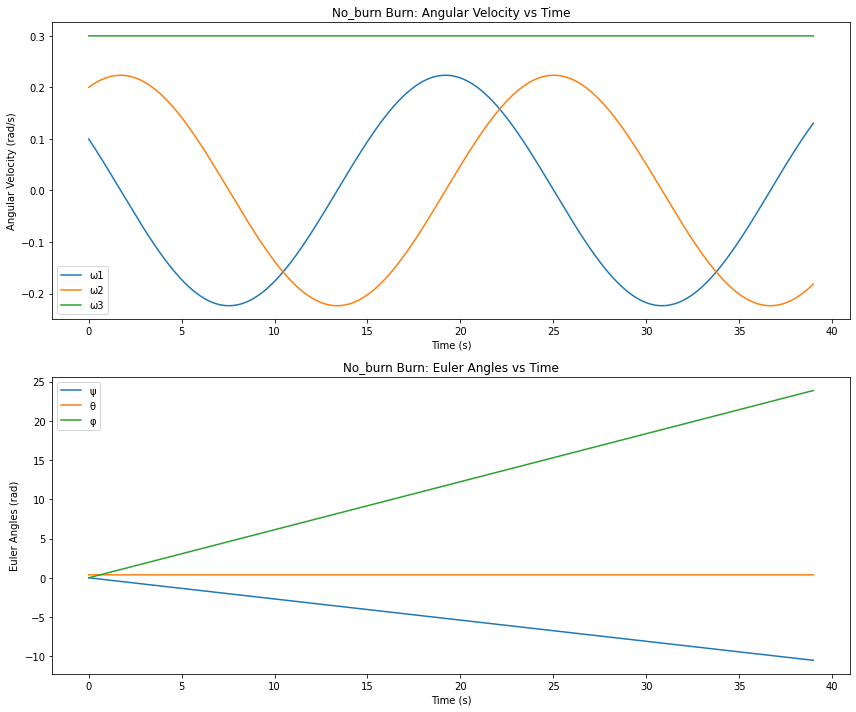

In [13]:
vms_no_burn = VariableMassCylinder(burn_type='no_burn')
# Run simulation
dt = 0.01  # time step
sol = vms_no_burn.simulate(dt=dt, w10=0.1, w20=0.2, w30=0.3)
vms_no_burn.plot_results()
# vms_no_burn.plot_analytical_comparison()

In [ ]:
# Get indices for t <= 10
mask = vms_no_burn.t <= 10
plt.plot(vms_no_burn.t[mask], vms_no_burn.sol.y[8][mask])
plt.show()


# Uniform burn analysis


def simulate: initial omegas:  0 0.2 0.3
m0:  1281.7698026646356


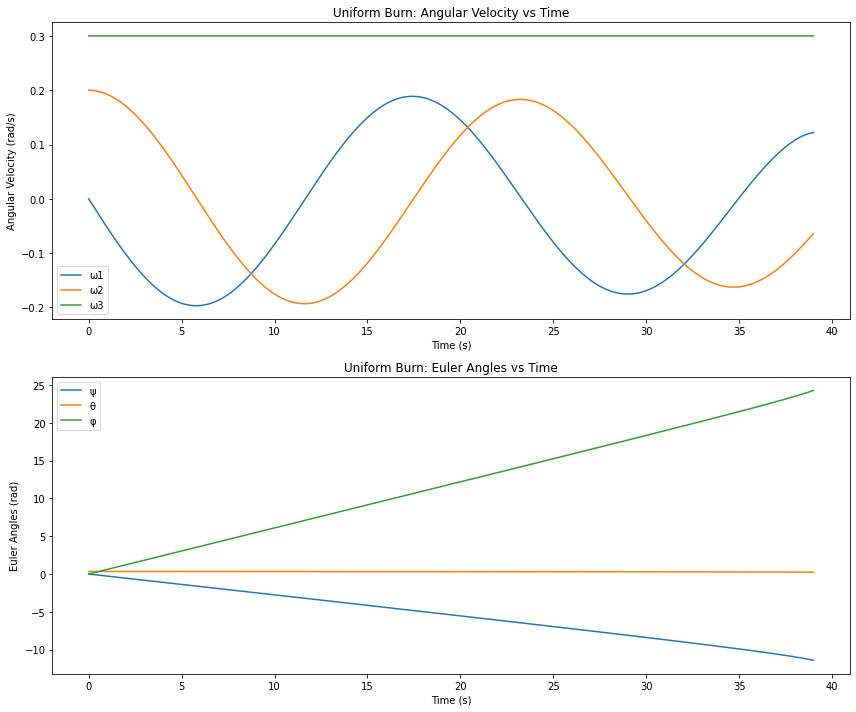

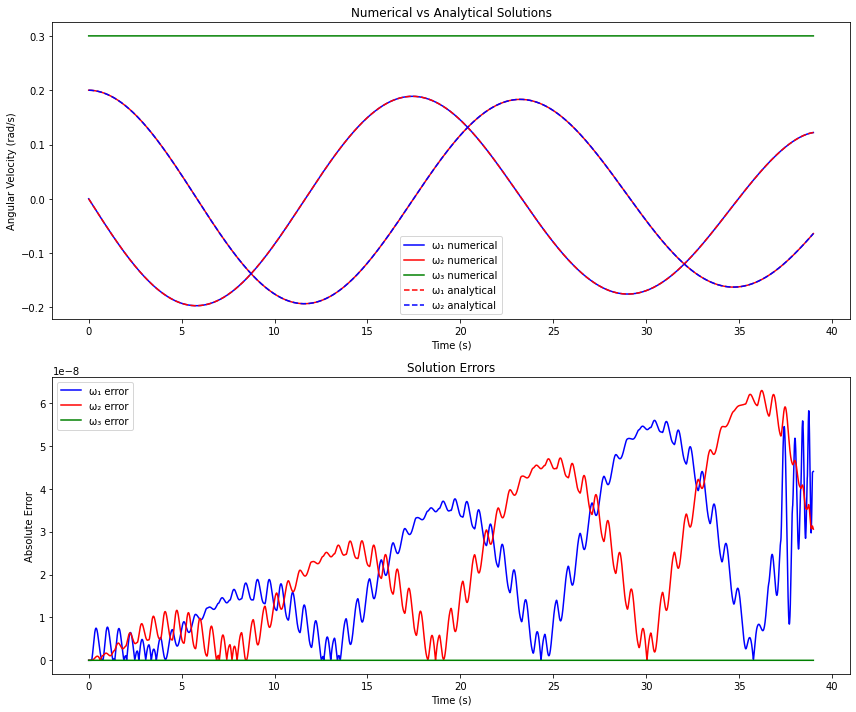

In [15]:
# Create instance for uniform burn
vms_uniform = VariableMassCylinder(burn_type='uniform')

# Run simulation
dt = 0.01  # time step
sol = vms_uniform.simulate(dt=dt, w10=0, w20=0.2, w30=0.3)
vms_uniform.plot_results()
vms_uniform.plot_analytical_comparison()

In [ ]:
vms_uniform.I1_symbolic_uniform, vms_uniform.I3_symbolic_uniform, vms_uniform.I1_dot_symbolic_uniform, vms_uniform.I3_dot_symbolic_uniform


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(vms_uniform.t, vms_uniform.omega1_numerical - vms_uniform.omega1_analytical)
ax1.set_ylabel('$\omega_1$ Error (Numerical - Analytical)')
ax1.set_xlabel('Time')

ax2.plot(vms_uniform.t, vms_uniform.omega2_numerical - vms_uniform.omega2_analytical)
ax2.set_ylabel('$\omega_2$ Error (Numerical - Analytical)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()

In [ ]:
vms_uniform.plot_theta_evolution()

In [ ]:
plt.plot(vms_uniform.t, vms_uniform.theta_numerical)
plt.show()


In [ ]:
# vms_uniform.plot_results()
# vms_uniform.plot_normalized_omegas()
# vms_uniform.plot_geometry()
# vms_uniform.plot_mass_inertia()
# vms_uniform.plot_omega_c()
vms_uniform.plot_moments_of_inertia()

# End burn analysis

def simulate: initial omegas:  0.1 0.2 0.3
END BURN SIMULATION: z0:  0.2


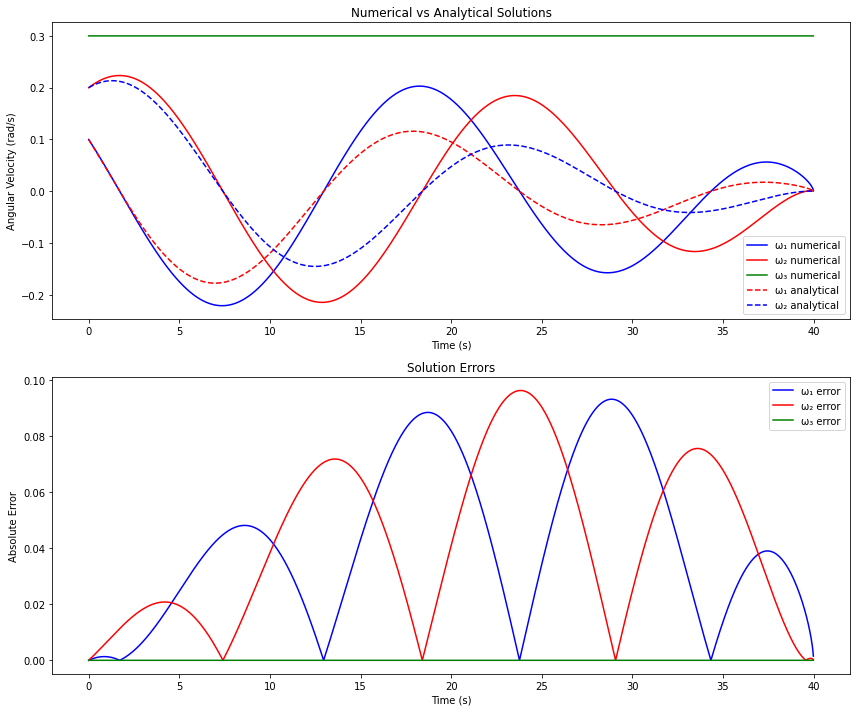

In [14]:
# Create instance for uniform burn
vms_end = VariableMassCylinder(burn_type='end')
# Run simulation
dt = 0.01  # time step
sol = vms_end.simulate(dt=dt, w10=0.1, w20=0.2, w30=0.3)
# vms_end.plot_results()
vms_end.plot_analytical_comparison()

In [ ]:
vms_end.plot_angles_vs_z_ratio()

In [ ]:
plt.plot(vms_end.t, vms_end.z)
plt.plot(vms_end.t, vms_end.ze)
plt.show()

In [ ]:
plt.plot(vms_end.t, vms_end.Gamma)
vms_end.z
omega_c_numerical = np.sqrt(vms_end.omega1_numerical**2 + vms_end.omega2_numerical**2)
Gamma_numerical = omega_c_numerical/omega_c_numerical[0]
Gamma_analytical = vms_end.Gamma
plt.plot(vms_end.t, Gamma_numerical)
plt.plot(vms_end.t, Gamma_analytical)
plt.show()
# plt.plot(vms_end.t, vms_end.h)
# plt.show()

In [ ]:
vms_end.plot_omega_c_analytical_vs_z_ratio()

In [ ]:
dt = vms_end.t[1] - vms_end.t[0]  # Get dt from time array
I3 = vms_end.sol.y[2]          # I3 values over time
I1 = vms_end.sol.y[1]          # I1 values over time
w3 = vms_end.sol.y[5]   
Chi_dot_theoretical = (1 - I3/I1) * w3
Chi_theoretical = np.cumsum(Chi_dot_theoretical * dt)

plt.figure(figsize=(10,6))
plt.plot(vms_end.t, vms_end.Chi, label='Chi from simulation')
plt.plot(vms_end.t, Chi_theoretical, '--', label='Chi theoretical')
plt.xlabel('Time (s)')
plt.ylabel('Chi (rad)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
vms_end.plot_omega12_vs_z_ratio()

In [ ]:
vms_end.plot_moments_of_inertia()

In [ ]:
vms_end.plot_theta_evolution()

In [ ]:
# Plot results
vms_end.plot_results()
# vms_end.plot_normalized_omegas()
# vms_end.plot_geometry()
# vms_end.plot_mass_inertia()
# vms_end.plot_omega_c()
vms_end.plot_analytical_comparison()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(vms_end.t, vms_end.omega1_numerical - vms_end.omega1_analytical)
ax1.set_ylabel('$\omega_1$ Error (Numerical - Analytical)')
ax1.set_xlabel('Time')

ax2.plot(vms_end.t, vms_end.omega2_numerical - vms_end.omega2_analytical)
ax2.set_ylabel('$\omega_2$ Error (Numerical - Analytical)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()

In [ ]:
omega_c_numerical = np.sqrt(vms_end.omega1_numerical**2 + vms_end.omega2_numerical**2,)
omega_c_analytical = np.sqrt(vms_end.omega1_analytical**2 + vms_end.omega2_analytical**2)
plt.plot(vms_end.t, omega_c_numerical, '--', label='numerical')
plt.plot(vms_end.t, omega_c_analytical)
plt.show()

In [ ]:
plt.plot(vms_end.t, vms_end.ze)
plt.show()

In [ ]:
plt.plot(vms_end.t, vms_end.omega1_analytical)
plt.show()

# Radial burn analysis

In [ ]:
# Create instance for uniform burn
vms_radial = VariableMassCylinder(burn_type='radial')

# Run simulation
dt = 0.01  # time step
sol = vms_radial.simulate(dt=dt, w10=0.1, w20=0.2, w30=0.3)
# vms_radial.plot_results()
vms_radial.plot_analytical_comparison()

In [ ]:
vms_radial.plot_euler_angles_vs_radius_ratio()

In [ ]:
vms_radial.plot_theta_evolution()

In [ ]:
vms_radial.plot_omega12_analytical_vs_radius_ratio()

In [ ]:
vms_radial.plot_omega12_vs_radius_ratio()
# vms_radial.plot_omega12_analytical_vs_radius_ratio()

In [ ]:
vms_radial.plot_euler_angles_vs_radius_ratio()

In [ ]:
vms_radial.plot_moments_of_inertia()

In [ ]:
# Plot results
# vms_radial.plot_results()
# vms_radial.plot_normalized_omegas()
# vms_radial.plot_geometry()
# vms_radial.plot_mass_inertia()
# vms_radial.plot_omega_c()
vms_radial.plot_analytical_comparison()

In [ ]:
plt.plot(vms_radial.t, vms_radial.omega1_numerical)
plt.plot(vms_radial.t, vms_radial.omega1_analytical, '--')
plt.show()

In [ ]:
plt.plot(vms_radial.t, vms_radial.omega2_numerical)
plt.plot(vms_radial.t, vms_radial.omega2_analytical, '--')
plt.show()

In [ ]:
omega_c_numerical = np.sqrt(vms_radial.omega1_numerical**2 + vms_radial.omega2_numerical**2,)
omega_c_analytical = np.sqrt(vms_radial.omega1_analytical**2 + vms_radial.omega2_analytical**2)
plt.plot(vms_radial.rsq/vms_radial.R**2, omega_c_numerical, '--', label='numerical')
plt.plot(vms_radial.rsq/vms_radial.R**2, omega_c_analytical)
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(vms_radial.t, vms_radial.omega1_numerical - vms_radial.omega1_analytical)
ax1.set_ylabel('$\omega_1$ Error (Numerical - Analytical)')
ax1.set_xlabel('Time')

ax2.plot(vms_radial.t, vms_radial.omega2_numerical - vms_radial.omega2_analytical)
ax2.set_ylabel('$\omega_2$ Error (Numerical - Analytical)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()
